# Intensity distributions at different bin sizes and state combinations
The bin size resembles the frame integration time, represented by the resample parameter of FluorophoreSystem.emitters().

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import pandas as pd
import src.fluorophore_systems as fs
import src.formulas as fo
from scipy.stats import poisson
import src.distributions as distr
import src.miscellaneous as mi

%load_ext autoreload
%autoreload 2

# S0 and S1

In [2]:
emission_rate = fo.calculate_emission_rate(quantum_yield=0.27, fluorescence_lifetime=1e-9)
internal_conv_rate = fo.calculate_internal_conversion_rate(quantum_yield=0.27, emission_rate=emission_rate)
transitions = [['S0_S1', 7e6, "excitation", "EXC", False],
               ['S1_S0', emission_rate, "fluorescent emission", "FLU", True],
               ['S1_S0', internal_conv_rate, "internal conversion S", "ICS", False]]
system = fs.FluorophoreSystem(number_fluorophores=1, distances=1, transitions=transitions)
system.simulate(n_steps=int(1e8), seed=100)
system.process()

In [3]:
system.unique_transitions

,name,rate,trivial_name,abbreviation,fluorescence
id,,,,,
0,S0_S1,7.00e+06,excitation,EXC,False
1,S1_S0,2.70e+08,fluorescent emission,FLU,True
2,S1_S0,7.30e+08,internal conversion S,ICS,False


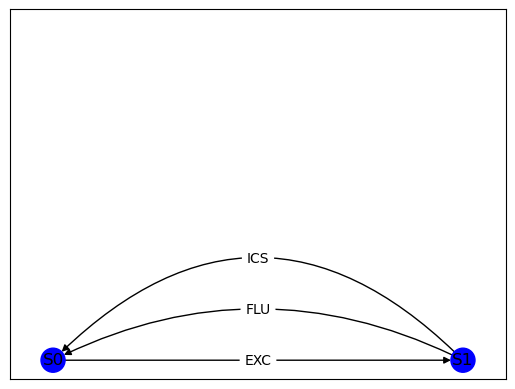

In [4]:
fig, ax = system.plot.network(type='planar')

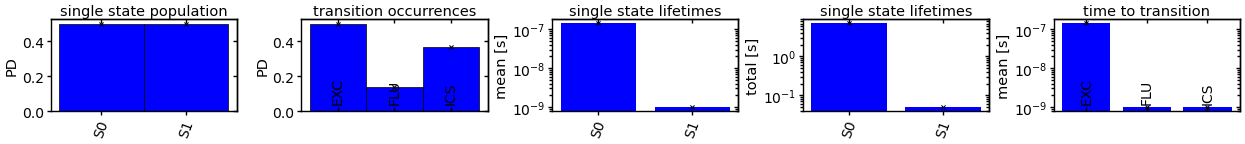

In [5]:
fig, ax = system.plot.populations(mode="single_states", single_fluorophores=False, scale=0.5, ncols=5, nrows=1, fig_width=25, fig_height=3, yscale='linear')
_, _ = system.plot.populations(mode='transitions', single_fluorophores=False, scale=1, fig=fig, axes=ax[0, 1], yscale='linear')
_, _ = system.plot.lifetimes(mode='single_states', statistic='mean', single_fluorophores=False, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.lifetimes(mode='single_states', statistic='total', single_fluorophores=False, scale=1, fig=fig, axes=ax[0, 3])
_, _ = system.plot.lifetimes(mode='transitions', single_fluorophores=False, scale=1, fig=fig, axes=ax[0, 4])
fig.tight_layout()

---

## 0.1 µs

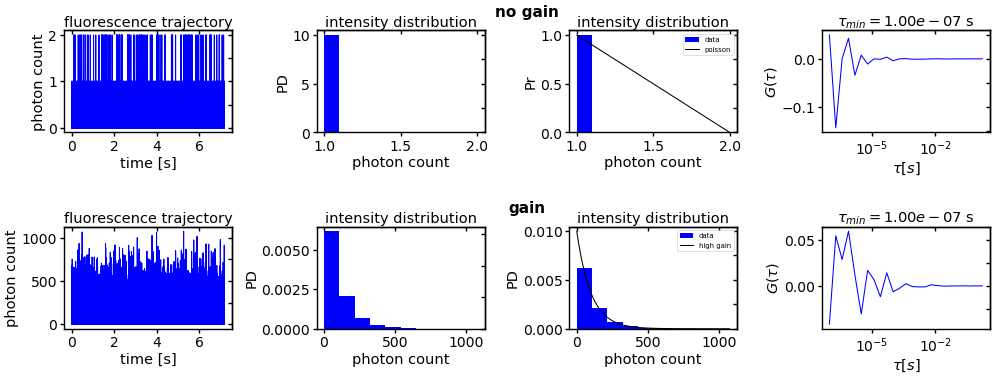

In [6]:
system.emitters(photon_collection_rate=0.01, resample="0.1us", emccd_gain=None)
system.fcs(normalize=True, log=True, m=2, deltat="0.1us")
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=8)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 1])
pois = poisson(mu=system.event_time_series[system.event_time_series != 0].mean()-1, loc=1)
lam = system.event_time_series.mean()
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 2], 
                                   plot_distribution=[pois, 'poisson'], density=False, legend=True)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[0, 3])
# emccd gain 
system.emitters(photon_collection_rate=0.01, resample="0.1us", emccd_gain=100)
system.fcs(normalize=True, log=True, m=2, deltat="0.1us")
_, _ = system.plot.emission_events(time_series=True, fig=fig, axes=ax[1, 0])
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 1])
high_gain_distr = distr.high_gain_amplification_noise_distribution(x_min=1, x_max=1000, v=lam, gain=100)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 2],
                                   plot_distribution=[high_gain_distr, 'high gain'], legend=True)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[1, 3])
mi.create_row_subtitles(fig, nrows=2, ncols=4, titles=['no gain', 'gain'])
fig.tight_layout()

---

## 1 µs

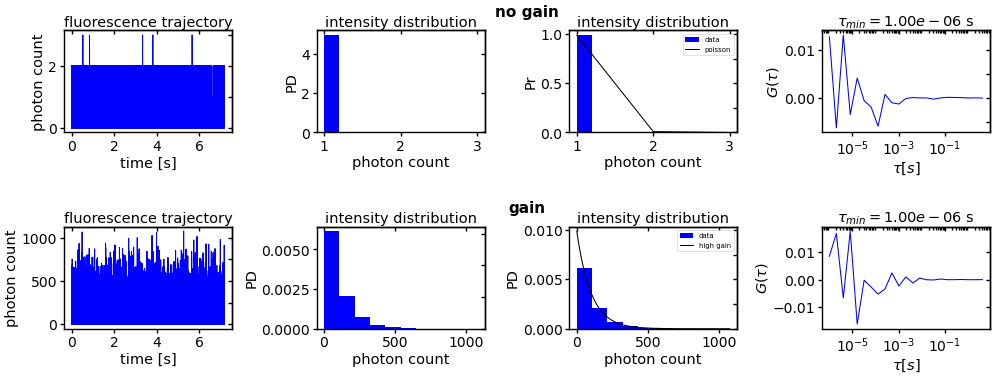

In [7]:
system.emitters(photon_collection_rate=0.01, resample="1us", emccd_gain=None)
system.fcs(normalize=True, log=True, m=2, deltat="1us")
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=8)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 1])
pois = poisson(mu=system.event_time_series[system.event_time_series != 0].mean()-1, loc=1)
lam = system.event_time_series.mean()
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 2], 
                                   plot_distribution=[pois, 'poisson'], legend=True, density=False)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[0, 3])
# emccd gain 
system.emitters(photon_collection_rate=0.01, resample="1us", emccd_gain=100)
system.fcs(normalize=True, log=True, m=2, deltat="1us")
_, _ = system.plot.emission_events(time_series=True, fig=fig, axes=ax[1, 0])
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 1])
high_gain_distr = distr.high_gain_amplification_noise_distribution(x_min=1, x_max=1500, v=lam, gain=100)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 2],
                                   plot_distribution=[high_gain_distr, 'high gain'], legend=True)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[1, 3])
mi.create_row_subtitles(fig, nrows=2, ncols=4, titles=['no gain', 'gain'])
fig.tight_layout()

---

## 10 µs

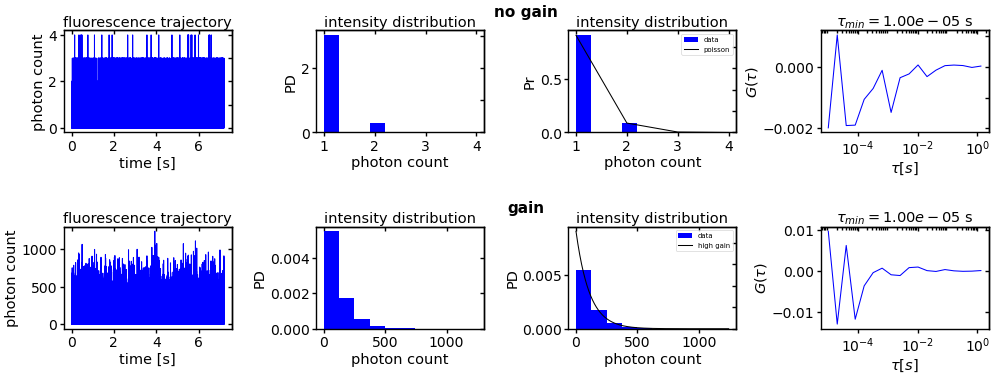

In [8]:
system.emitters(photon_collection_rate=0.01, resample="10us", emccd_gain=None)
system.fcs(normalize=True, log=True, m=2, deltat="10us")
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=8)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 1])
pois = poisson(mu=system.event_time_series[system.event_time_series != 0].mean()-1, loc=1)
lam = system.event_time_series.mean()
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 2], 
                                   plot_distribution=[pois, 'poisson'], legend=True, density=False)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[0, 3])
# emccd gain 
system.emitters(photon_collection_rate=0.01, resample="10us", emccd_gain=100)
system.fcs(normalize=True, log=True, m=2, deltat="10us")
_, _ = system.plot.emission_events(time_series=True, fig=fig, axes=ax[1, 0])
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 1])
high_gain_distr = distr.high_gain_amplification_noise_distribution(x_min=1, x_max=2000, v=lam, gain=100)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 2],
                                   plot_distribution=[high_gain_distr, 'high gain'], legend=True)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[1, 3])
mi.create_row_subtitles(fig, nrows=2, ncols=4, titles=['no gain', 'gain'])
fig.tight_layout()

---

## 0.1 ms

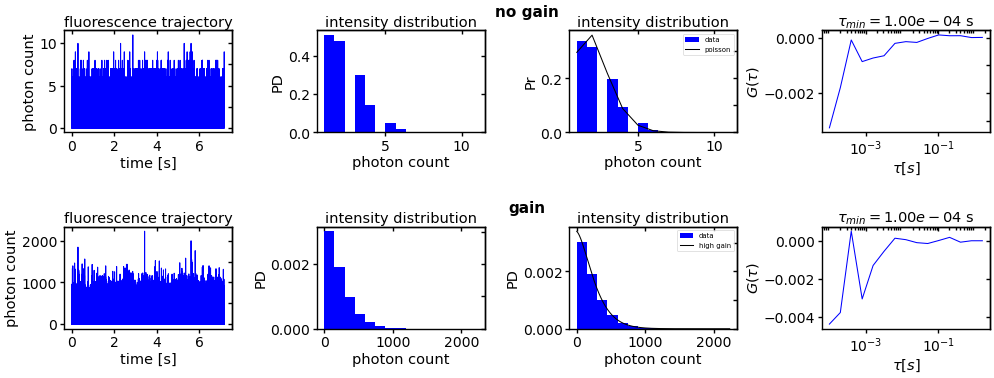

In [12]:
system.emitters(photon_collection_rate=0.01, resample="0.1ms", emccd_gain=None)
system.fcs(normalize=True, log=True, m=2, deltat="0.1ms")
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=8)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 1], bins=15)
pois = poisson(mu=system.event_time_series[system.event_time_series != 0].mean()-1, loc=1)
lam = system.event_time_series.mean()
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 2], 
                                   plot_distribution=[pois, 'poisson'], legend=True, bins=15, density=False)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[0, 3])
# emccd gain 
system.emitters(photon_collection_rate=0.01, resample="0.1ms", emccd_gain=100)
system.fcs(normalize=True, log=True, m=2, deltat="0.1ms")
_, _ = system.plot.emission_events(time_series=True, fig=fig, axes=ax[1, 0])
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 1], bins=15)
high_gain_distr = distr.high_gain_amplification_noise_distribution(x_min=1, x_max=7000, v=lam, gain=100)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 2],
                                   plot_distribution=[high_gain_distr, 'high gain'], legend=True, bins=15)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[1, 3])
mi.create_row_subtitles(fig, nrows=2, ncols=4, titles=['no gain', 'gain'])
fig.tight_layout()

---

## 1 ms

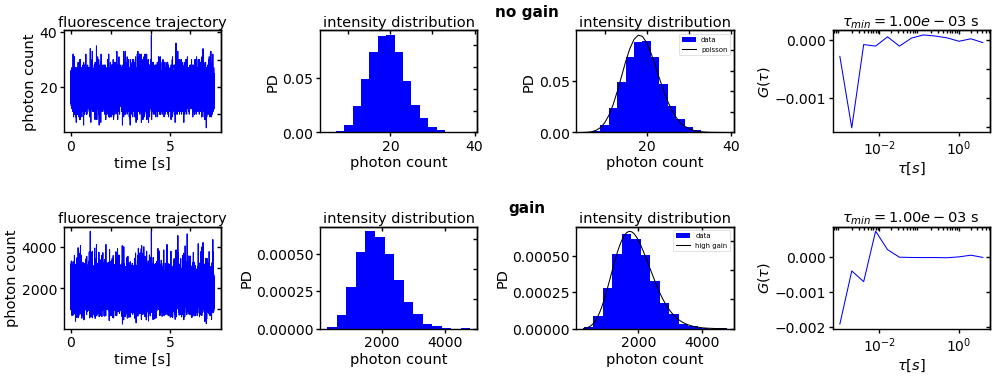

In [18]:
system.emitters(photon_collection_rate=0.01, resample="1ms", emccd_gain=None)
system.fcs(normalize=True, log=True, m=2, deltat="1ms")
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=8)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 1], bins=17)
pois = poisson(mu=system.event_time_series[system.event_time_series != 0].mean()-1, loc=1)
lam = system.event_time_series.mean()
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 2], 
                                   plot_distribution=[pois, 'poisson'], legend=True, bins=17)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[0, 3])
# emccd gain 
system.emitters(photon_collection_rate=0.01, resample="1ms", emccd_gain=100)
system.fcs(normalize=True, log=True, m=2, deltat="1ms")
_, _ = system.plot.emission_events(time_series=True, fig=fig, axes=ax[1, 0])
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 1], bins=15)
high_gain_distr = distr.high_gain_amplification_noise_distribution(x_min=1, x_max=7000, v=lam, gain=100)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 2], 
                                   plot_distribution=[high_gain_distr, 'high gain'], legend=True, bins=15)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[1, 3])
mi.create_row_subtitles(fig, nrows=2, ncols=4, titles=['no gain', 'gain'])
fig.tight_layout()

---

## 10 ms

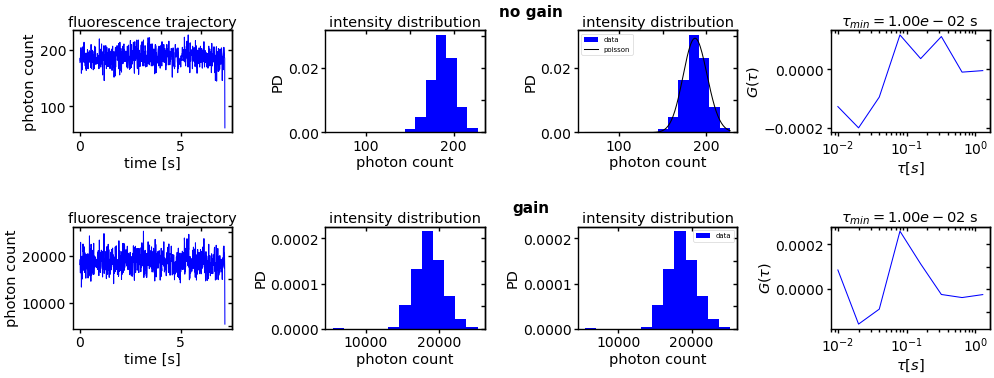

In [11]:
system.emitters(photon_collection_rate=0.01, resample="10ms", emccd_gain=None)
system.fcs(normalize=True, log=True, m=2, deltat="10ms")
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=8)
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 1], bins=14)
pois = poisson(mu=system.event_time_series[system.event_time_series != 0].mean()-1, loc=1)
lam = system.event_time_series.mean()
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[0, 2], 
                                   plot_distribution=[pois, 'poisson'], legend=True, bins=14)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[0, 3])
# emccd gain 
system.emitters(photon_collection_rate=0.01, resample="10ms", emccd_gain=100)
system.fcs(normalize=True, log=True, m=2, deltat="10ms")
_, _ = system.plot.emission_events(time_series=True, fig=fig, axes=ax[1, 0])
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 1], bins=13)
# photon counts to high to calculate high gain amplification distribution
_, _ = system.plot.emission_events(time_series=False, fig=fig, axes=ax[1, 2], legend=True, bins=13)
_, _ = system.plot.fcs(normalize_to=None, fig=fig, axes=ax[1, 3])
mi.create_row_subtitles(fig, nrows=2, ncols=4, titles=['no gain', 'gain'])
fig.tight_layout()